# Experiment: Analyse des prix des ecarts 2025 (MMA_HECAR)

Objectif:
- Charger les 12 fichiers `MMA_HECAR_2025*.csv`.
- Ignorer la premiere ligne de chaque fichier.
- Fusionner toutes les donnees dans un dataframe unique.
- Analyser la distribution des 2 dernieres colonnes (prix) selon les composantes temporelles.

Composantes temporelles ciblees:
- `weekday`, `month`, `hour`, `minute`
- `holiday_fr` (jours feries en France)
- combinaisons de ces composantes (ex: `month x weekday x hour x minute`)


In [9]:
from __future__ import annotations

import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)


## 1) Chargement et fusion des 12 fichiers

Remarque: la premiere ligne de chaque fichier est un titre texte (a ignorer).


In [10]:
from src.data_treatment_prix_ecarts import build_df_all

df_all = build_df_all()

df_all.head()

# see daylight saving time, one day with 23 hours.
df_all[(df_all["Heure de début"]>=datetime.datetime(2025,3,30,1))&(df_all["Heure de début"]<=datetime.datetime(2025,3,30,4))]
df_all[(df_all["Heure de début"]>=datetime.datetime(2025,10,26,1))&(df_all["Heure de début"]<=datetime.datetime(2025,10,26,4))]


,file,rows,first_timestamp,month_from_data
0,MMA_HECAR_2025 (10).csv,2976,2025-01-01,2025-01
1,MMA_HECAR_2025 (9).csv,2688,2025-02-01,2025-02
2,MMA_HECAR_2025 (8).csv,2972,2025-03-01,2025-03
3,MMA_HECAR_2025 (7).csv,2880,2025-04-01,2025-04
4,MMA_HECAR_2025 (11).csv,2976,2025-05-01,2025-05
5,MMA_HECAR_2025 (6).csv,2880,2025-06-01,2025-06
6,MMA_HECAR_2025 (5).csv,2976,2025-07-01,2025-07
7,MMA_HECAR_2025 (4).csv,2976,2025-08-01,2025-08
8,MMA_HECAR_2025 (3).csv,2880,2025-09-01,2025-09
9,MMA_HECAR_2025 (2).csv,2980,2025-10-01,2025-10


,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file
28608,2025-10-26 01:00:00,2025-10-26 01:15:00,293.29,BAISSE,12.79,14.21,MMA_HECAR_2025 (2).csv
28609,2025-10-26 01:15:00,2025-10-26 01:30:00,510.63,BAISSE,12.67,14.09,MMA_HECAR_2025 (2).csv
28610,2025-10-26 01:30:00,2025-10-26 01:45:00,318.49,BAISSE,8.34,9.28,MMA_HECAR_2025 (2).csv
28611,2025-10-26 01:45:00,2025-10-26 02:00:00,423.90,BAISSE,6.40,7.12,MMA_HECAR_2025 (2).csv
28612,2025-10-26 02:00:00,2025-10-26 02:15:00,247.27,BAISSE,3.99,4.43,MMA_HECAR_2025 (2).csv
28613,2025-10-26 02:15:00,2025-10-26 02:30:00,227.90,BAISSE,-0.07,-0.07,MMA_HECAR_2025 (2).csv
28614,2025-10-26 02:30:00,2025-10-26 02:45:00,210.42,BAISSE,-0.98,-0.88,MMA_HECAR_2025 (2).csv
28615,2025-10-26 02:45:00,2025-10-26 02:00:00,267.87,BAISSE,-0.88,-0.80,MMA_HECAR_2025 (2).csv
28616,2025-10-26 02:00:00,2025-10-26 02:15:00,943.98,BAISSE,-11.61,-10.45,MMA_HECAR_2025 (2).csv
28617,2025-10-26 02:15:00,2025-10-26 02:30:00,662.37,BAISSE,-13.57,-12.21,MMA_HECAR_2025 (2).csv


# 1.2) Transform into UTC

In [7]:
for col in ["Heure de début", "Heure de fin"]:
    s = pd.to_datetime(df_all[col], errors="raise")

    local = s.dt.tz_localize(
        "Europe/Paris",
        ambiguous="infer",   # handles the 25h day (duplicated 02:00-02:45)
        nonexistent="raise"  # good safety check for the 23h day
    )

    df_all[f"{col} (UTC)"] = local.dt.tz_convert("UTC")




# see that all dates now have 24 hours
df_all[(df_all["Heure de début (UTC)"]>=datetime.datetime(2025,10,26,0, tzinfo=datetime.UTC))&(df_all["Heure de début (UTC)"]<=datetime.datetime(2025,10,26,3, tzinfo=datetime.UTC))]


,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file,Heure de début (UTC),Heure de fin (UTC)
28612,2025-10-26 02:00:00,2025-10-26 02:15:00,247.27,BAISSE,3.99,4.43,MMA_HECAR_2025 (2).csv,2025-10-26 00:00:00+00:00,2025-10-26 00:15:00+00:00
28613,2025-10-26 02:15:00,2025-10-26 02:30:00,227.90,BAISSE,-0.07,-0.07,MMA_HECAR_2025 (2).csv,2025-10-26 00:15:00+00:00,2025-10-26 00:30:00+00:00
28614,2025-10-26 02:30:00,2025-10-26 02:45:00,210.42,BAISSE,-0.98,-0.88,MMA_HECAR_2025 (2).csv,2025-10-26 00:30:00+00:00,2025-10-26 00:45:00+00:00
28615,2025-10-26 02:45:00,2025-10-26 02:00:00,267.87,BAISSE,-0.88,-0.80,MMA_HECAR_2025 (2).csv,2025-10-26 00:45:00+00:00,2025-10-26 01:00:00+00:00
28616,2025-10-26 02:00:00,2025-10-26 02:15:00,943.98,BAISSE,-11.61,-10.45,MMA_HECAR_2025 (2).csv,2025-10-26 01:00:00+00:00,2025-10-26 01:15:00+00:00
28617,2025-10-26 02:15:00,2025-10-26 02:30:00,662.37,BAISSE,-13.57,-12.21,MMA_HECAR_2025 (2).csv,2025-10-26 01:15:00+00:00,2025-10-26 01:30:00+00:00
28618,2025-10-26 02:30:00,2025-10-26 02:45:00,560.06,BAISSE,-18.92,-17.02,MMA_HECAR_2025 (2).csv,2025-10-26 01:30:00+00:00,2025-10-26 01:45:00+00:00
28619,2025-10-26 02:45:00,2025-10-26 03:00:00,596.57,BAISSE,-19.24,-17.30,MMA_HECAR_2025 (2).csv,2025-10-26 01:45:00+00:00,2025-10-26 02:00:00+00:00
28620,2025-10-26 03:00:00,2025-10-26 03:15:00,549.78,BAISSE,-17.59,-15.83,MMA_HECAR_2025 (2).csv,2025-10-26 02:00:00+00:00,2025-10-26 02:15:00+00:00
28621,2025-10-26 03:15:00,2025-10-26 03:30:00,564.32,BAISSE,-16.70,-15.02,MMA_HECAR_2025 (2).csv,2025-10-26 02:15:00+00:00,2025-10-26 02:30:00+00:00


## 2) Preparation des variables temporelles et des colonnes prix


In [ ]:
# price_cols = df_all.columns[-3:-1].tolist() if df_all.columns[-1] == 'source_file' else df_all.columns[-2:].tolist()
# plus simple
price_cols = ['Prix de Règlements des Ecarts Positifs (Euros/MWh)']

# Enforce numeric type for the 2 target price columns.
for col in price_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

dt = df_all[start_ts_col]
df_all['month'] = dt.dt.month
df_all['month_name'] = dt.dt.month_name()
df_all['weekday'] = dt.dt.day_name()
df_all['weekday_num'] = dt.dt.weekday
df_all['hour'] = dt.dt.hour
df_all['minute'] = dt.dt.minute
df_all['week_num'] = dt.dt.isocalendar().week

def easter_sunday(year: int) -> datetime.date:
    # Anonymous Gregorian algorithm
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    return datetime.date(year, month, day)

def french_holidays(year: int) -> dict[datetime.date, str]:
    easter = easter_sunday(year)
    return {
        datetime.date(year, 1, 1): 'New Year',
        easter + datetime.timedelta(days=1): 'Easter Monday',
        datetime.date(year, 5, 1): 'Labour Day',
        datetime.date(year, 5, 8): 'Victory in Europe Day',
        easter + datetime.timedelta(days=39): 'Ascension Day',
        easter + datetime.timedelta(days=50): 'Whit Monday',
        datetime.date(year, 7, 14): 'Bastille Day',
        datetime.date(year, 8, 15): 'Assumption Day',
        datetime.date(year, 11, 1): 'All Saints Day',
        datetime.date(year, 11, 11): 'Armistice Day',
        datetime.date(year, 12, 25): 'Christmas Day',
    }

years = sorted(df_all[start_ts_col].dt.year.dropna().unique().astype(int))
holiday_map = {}
for year in years:
    holiday_map.update(french_holidays(year))

df_all['date_only'] = dt.dt.date
df_all['holiday_fr'] = df_all['date_only'].map(holiday_map).fillna('Non-holiday')
df_all['is_holiday_fr'] = df_all['holiday_fr'].ne('Non-holiday')

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
holiday_order = ['Non-holiday'] + sorted(set(holiday_map.values()))

df_all['weekday'] = pd.Categorical(df_all['weekday'], categories=weekday_order, ordered=True)
df_all['month_name'] = pd.Categorical(df_all['month_name'], categories=month_order, ordered=True)
df_all['holiday_fr'] = pd.Categorical(df_all['holiday_fr'], categories=holiday_order, ordered=True)

print('Timestamp columns:', [start_ts_col, end_ts_col])
print('Price columns:', price_cols)
print('Combined shape:', df_all.shape)
print('French holidays covered:', sorted(set(v for v in holiday_map.values())))
df_all[price_cols].describe().T

#ajout Loris
# time within a day, emulated from kaggle
# x for seasonal plot: numeric minutes in day (safe for seaborn)
df_all["min_in_day"] = (
    df_all["Heure de début (UTC"].dt.hour * 60
    + df_all["Heure de début (UTC"].dt.minute
)


Timestamp columns: ['Heure de début', 'Heure de fin']
Price columns: ['Prix de Règlements des Ecarts Positifs (Euros/MWh)']
Combined shape: (35040, 17)
French holidays covered: ['All Saints Day', 'Armistice Day', 'Ascension Day', 'Assumption Day', 'Bastille Day', 'Christmas Day', 'Easter Monday', 'Labour Day', 'New Year', 'Victory in Europe Day', 'Whit Monday']


In [ ]:
# df_all.date_only.value_counts()
# montre  2025-10-26    100 
# et 2025-03-30     92

# Il FAUT localiser le df, puis convertir en UTC.
df_all[(df_all.date_only== datetime.date(2025,3,30))&(df_all.hour>=1)&(df_all.hour<=4)]
# montre un créneau qui commence à 1:45 à 3:00


,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file,month,month_name,weekday,weekday_num,hour,minute,week_num,date_only,holiday_fr,is_holiday_fr,min_in_day,weekend_tag
8452,2025-03-30 01:00:00,2025-03-30 01:15:00,698.65,BAISSE,16.20,18.12,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,1,0,13,2025-03-30,Non-holiday,False,60,True
8453,2025-03-30 01:15:00,2025-03-30 01:30:00,687.38,BAISSE,10.76,12.04,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,1,15,13,2025-03-30,Non-holiday,False,75,True
8454,2025-03-30 01:30:00,2025-03-30 01:45:00,814.80,BAISSE,9.75,10.91,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,1,30,13,2025-03-30,Non-holiday,False,90,True
8455,2025-03-30 01:45:00,2025-03-30 03:00:00,937.05,BAISSE,8.36,9.36,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,1,45,13,2025-03-30,Non-holiday,False,105,True
8456,2025-03-30 03:00:00,2025-03-30 03:15:00,423.55,BAISSE,7.82,8.74,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,3,0,13,2025-03-30,Non-holiday,False,180,True
8457,2025-03-30 03:15:00,2025-03-30 03:30:00,486.80,BAISSE,9.72,10.88,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,3,15,13,2025-03-30,Non-holiday,False,195,True
8458,2025-03-30 03:30:00,2025-03-30 03:45:00,427.14,BAISSE,10.20,11.42,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,3,30,13,2025-03-30,Non-holiday,False,210,True
8459,2025-03-30 03:45:00,2025-03-30 04:00:00,325.82,BAISSE,4.14,4.64,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,3,45,13,2025-03-30,Non-holiday,False,225,True
8460,2025-03-30 04:00:00,2025-03-30 04:15:00,326.73,BAISSE,-2.22,-1.98,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,4,0,13,2025-03-30,Non-holiday,False,240,True
8461,2025-03-30 04:15:00,2025-03-30 04:30:00,287.00,BAISSE,-131.70,-117.70,MMA_HECAR_2025 (8).csv,3,March,Sunday,6,4,15,13,2025-03-30,Non-holiday,False,255,True


In [14]:

df_all["weekend_tag"] = df_all["weekday_num"].isin([5,6])

In [8]:
df_all[df_all.week_num == 1].date_only.unique()

array([datetime.date(2025, 1, 1), datetime.date(2025, 1, 2),
       datetime.date(2025, 1, 3), datetime.date(2025, 1, 4),
       datetime.date(2025, 1, 5), datetime.date(2025, 12, 29),
       datetime.date(2025, 12, 30), datetime.date(2025, 12, 31)],
      dtype=object)

In [10]:
missing_summary = df_all[[start_ts_col, end_ts_col] + price_cols].isna().sum().rename('missing_count')
missing_summary


Heure de début    0
Heure de fin      0
is_holiday_fr     0
min_in_day        0
Name: missing_count, dtype: int64

## 3) Distribution globale des 2 colonnes prix


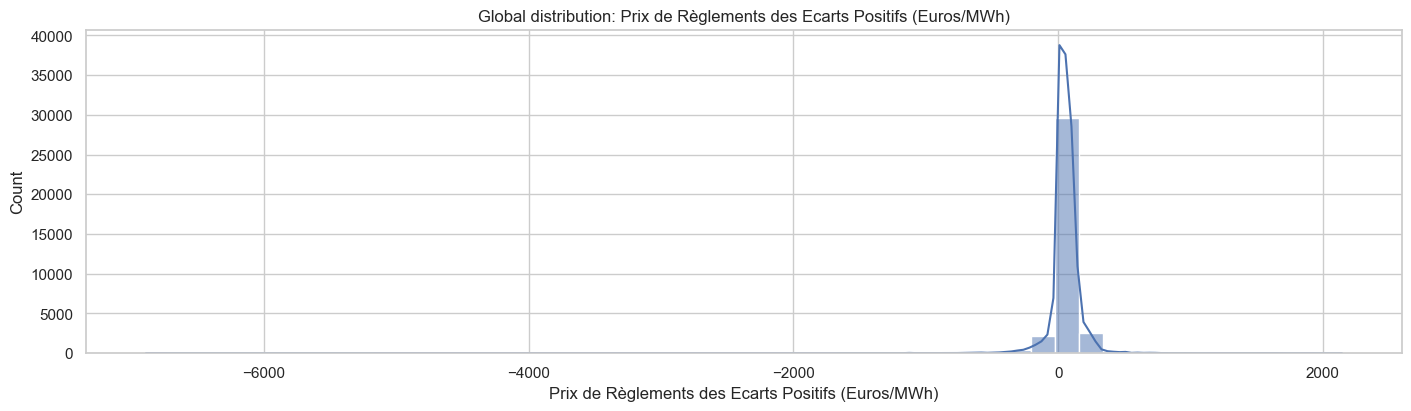

In [25]:
fig, axes = plt.subplots(1, len(price_cols), figsize=(14, 4), constrained_layout=True)
if len(price_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, price_cols):
    sns.histplot(data=df_all, x=col, kde=True, bins=50, ax=ax)
    ax.set_title(f'Global distribution: {col}')

plt.show()


## 4) Analyse par composantes temporelles individuelles

Composantes: `weekday`, `month_name`, `hour`, `minute`, `holiday_fr`, `is_holiday_fr`.


In [9]:

single_components = ['month_name', 'week_num', 'weekday', 'hour', 'minute', 'holiday_fr', 'is_holiday_fr']

# create all possible combinations
from itertools import combinations  
combined_components = [comb for i in range(1, len(single_components) + 1) for comb in combinations(single_components, i)]  
print(combined_components)


[('month_name',), ('week_num',), ('weekday',), ('hour',), ('minute',), ('holiday_fr',), ('is_holiday_fr',), ('month_name', 'week_num'), ('month_name', 'weekday'), ('month_name', 'hour'), ('month_name', 'minute'), ('month_name', 'holiday_fr'), ('month_name', 'is_holiday_fr'), ('week_num', 'weekday'), ('week_num', 'hour'), ('week_num', 'minute'), ('week_num', 'holiday_fr'), ('week_num', 'is_holiday_fr'), ('weekday', 'hour'), ('weekday', 'minute'), ('weekday', 'holiday_fr'), ('weekday', 'is_holiday_fr'), ('hour', 'minute'), ('hour', 'holiday_fr'), ('hour', 'is_holiday_fr'), ('minute', 'holiday_fr'), ('minute', 'is_holiday_fr'), ('holiday_fr', 'is_holiday_fr'), ('month_name', 'week_num', 'weekday'), ('month_name', 'week_num', 'hour'), ('month_name', 'week_num', 'minute'), ('month_name', 'week_num', 'holiday_fr'), ('month_name', 'week_num', 'is_holiday_fr'), ('month_name', 'weekday', 'hour'), ('month_name', 'weekday', 'minute'), ('month_name', 'weekday', 'holiday_fr'), ('month_name', 'weekd

In [10]:
def grouped_distribution_stats(df: pd.DataFrame, group_cols: list[str], value_col: str) -> pd.DataFrame:
    quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
    stats = (
        df.groupby(group_cols, observed=True)[value_col]
        .describe(percentiles=quantiles)
        .reset_index()
        .sort_values('std', ascending=True)
    )
    return stats


In [ ]:

# for component in single_components:
#     print(f'===== Component(s): {component} =====')
#     for price_col in price_cols:
#         print(f'-- {price_col} | groups={len(stats)}')
#         stats = grouped_distribution_stats(df_all, list(component), price_col)
#         display(stats)

aggregated_res = []
aggregated_mean = []
aggreaged_std = []
for group_cols in combined_components:
    print(f'===== Component(s): {group_cols} =====')
    for price_col in price_cols:
        stats = grouped_distribution_stats(df_all, list(group_cols), price_col)
        print(f'-- {price_col} | groups={len(stats)}')
        # display(stats)
        #
        aggreaged_std.append(stats["std"].std())
        aggregated_mean.append(stats["std"].mean())

aggregated_res = pd.DataFrame(data = {"mean": aggregated_mean, "std": aggreaged_std}, index = combined_components )


In [1]:

aggregated_res.sort_values(by=["mean"]).head(20)

NameError: name 'aggregated_res' is not defined

<Axes: xlabel='std', ylabel='mean'>

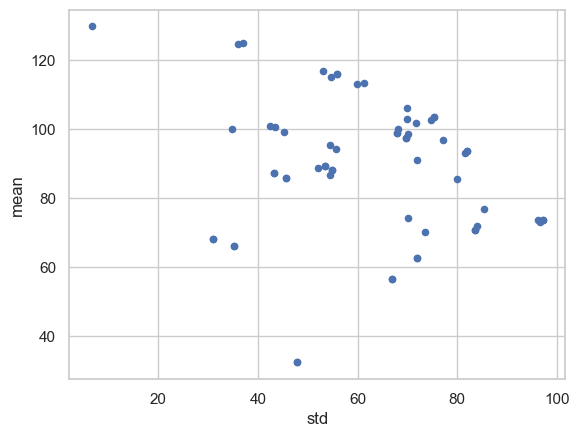

In [54]:
aggregated_res.plot.scatter(x="std", y="mean")

(minute, holiday_fr) a une std mean à 66 et une std de std à 35
(hour, holiday_fr) a une std mean à 32 et une std de std à 47
ça fait des bins pas réguliers, pas bon.

=> Il n'y a aucune façon de grouper qui produise des écarts types faibles et constants.
est-ce que ça veut dire que ces façons de grouper sont de mauvais indicateurs ? 

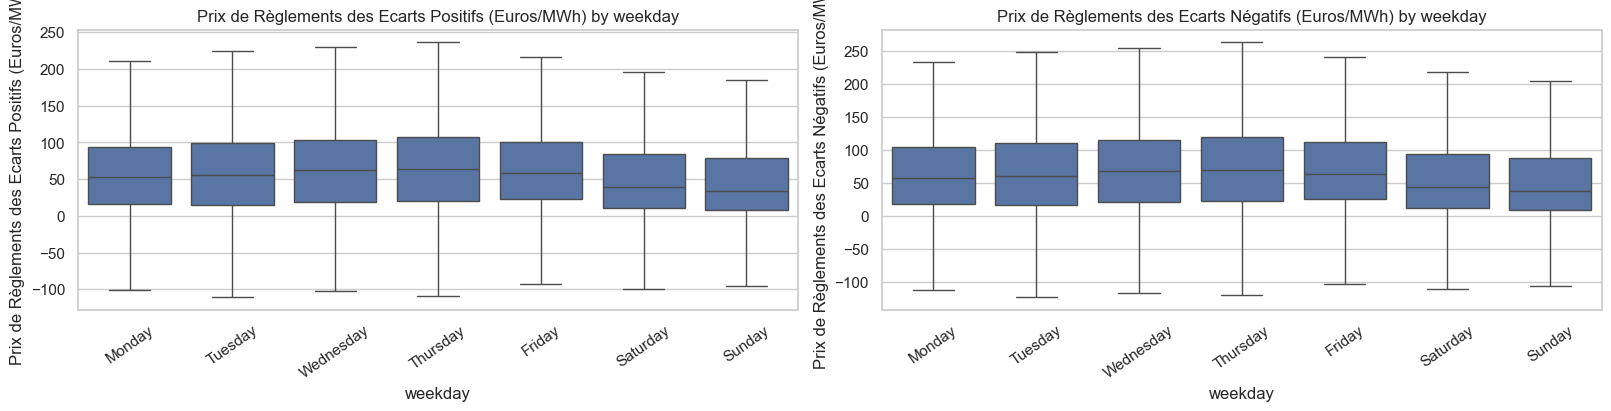

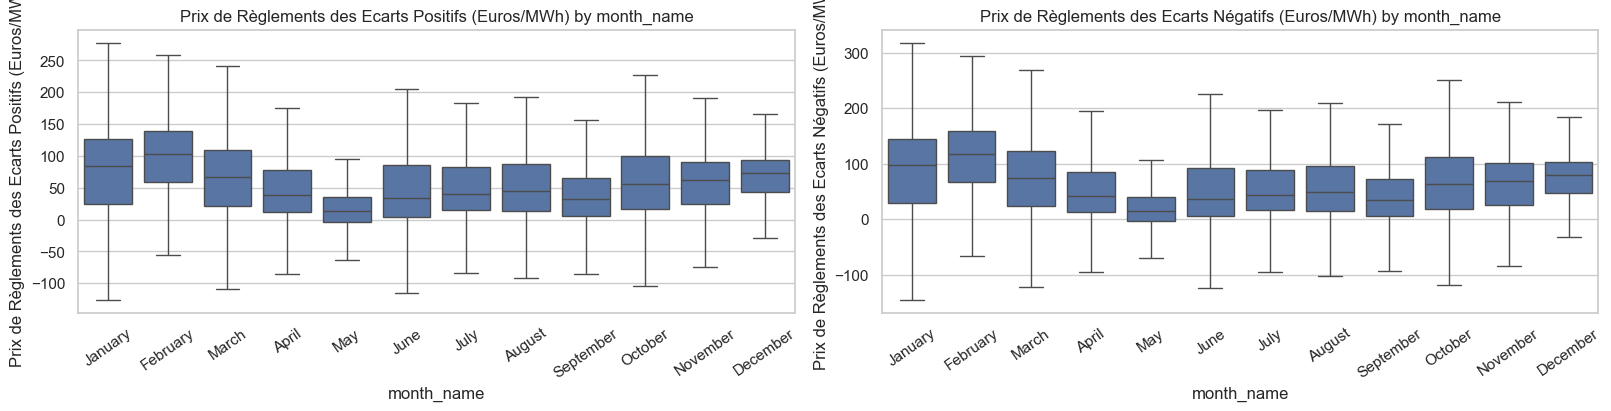

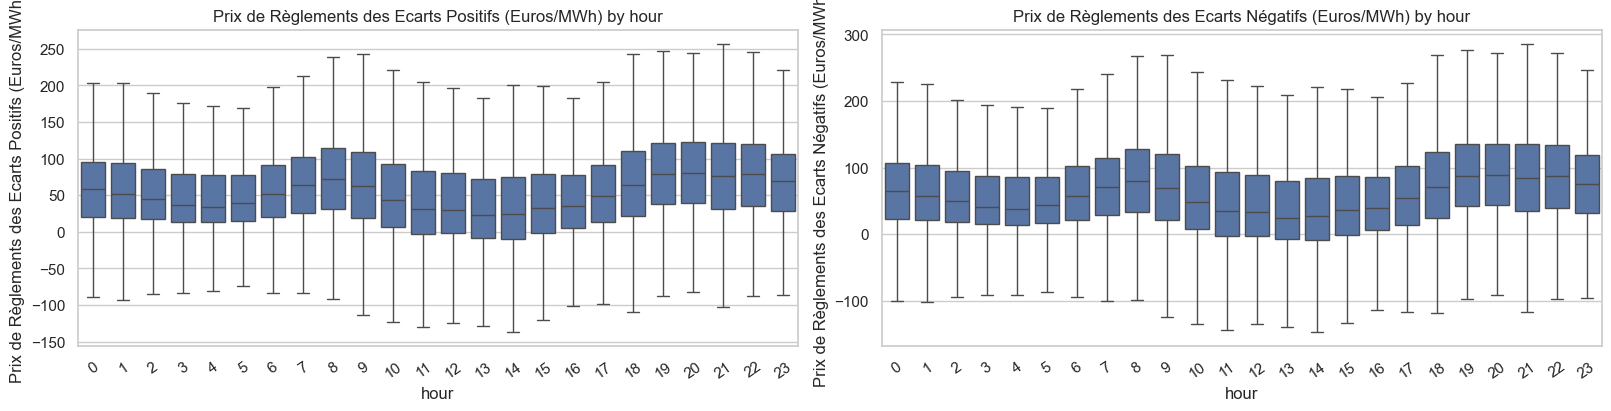

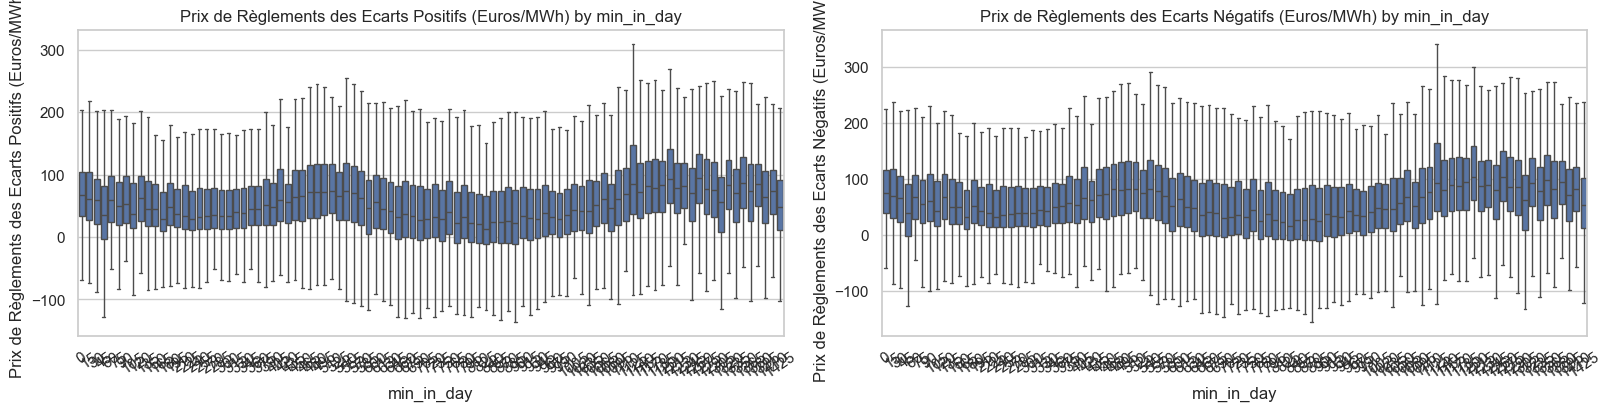

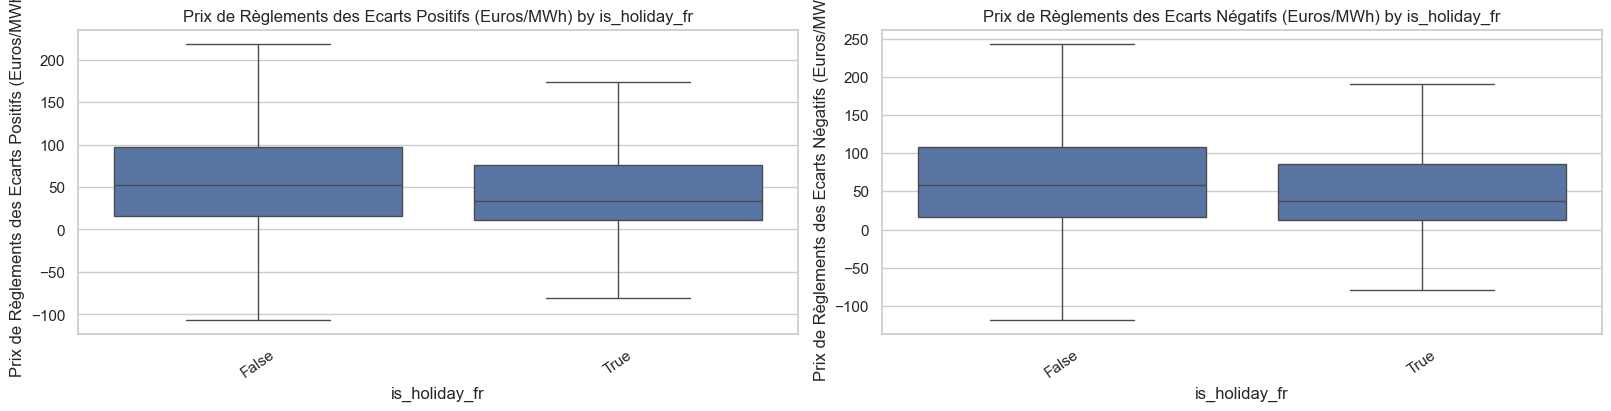

In [21]:
for component in ['weekday', 'month_name', 'hour', 'min_in_day', 'is_holiday_fr']:
    fig, axes = plt.subplots(1, len(price_cols), figsize=(16, 4), constrained_layout=True)
    if len(price_cols) == 1:
        axes = [axes]

    for ax, price_col in zip(axes, price_cols):
        sns.boxplot(data=df_all, x=component, y=price_col, ax=ax, showfliers=False)
        ax.set_title(f'{price_col} by {component}')
        ax.tick_params(axis='x', rotation=35)

    plt.show()


## 5) Combinaisons de composantes temporelles

Exemples: `month x weekday x hour x minute`, `month_name x weekday`, `weekday x hour`, `month_name x hour`, `is_holiday_fr x weekday x hour`.


In [36]:
combined_components = [
    ['month_name', 'weekday', 'hour', 'minute'],
    ['weekday', 'hour', 'minute'],
    ['weekday', 'hour'],
    ['month_name', 'weekday'],
    ['month_name', 'hour', 'minute'],
    ['is_holiday_fr', 'weekday', 'hour'],
]

for group_cols in combined_components:
    print(f'===== Combined components: {group_cols} =====')
    for price_col in price_cols:
        stats = grouped_distribution_stats(df_all, group_cols, price_col)
        print(f'-- {price_col} | groups={len(stats)}')
        display(stats)


===== Combined components: ['month_name', 'weekday', 'hour', 'minute'] =====
-- Prix de Règlements des Ecarts Positifs (Euros/MWh) | groups=8064


,month_name,weekday,hour,minute,count,mean,std,min,10%,25%,50%,75%,90%,max
2885,May,Wednesday,1,15,4.0,11.6300,2.200197,8.56,9.517,10.9525,12.125,12.8025,13.347,13.71
3244,May,Saturday,19,0,5.0,10.9020,2.779851,8.25,8.898,9.8700,10.290,10.4800,13.564,15.62
4643,July,Sunday,8,45,4.0,15.8825,3.028975,13.02,13.233,13.5525,15.545,17.8750,18.802,19.42
2708,May,Monday,5,0,4.0,1.0725,3.090872,-3.27,-1.779,0.4575,1.755,2.3700,3.378,4.05
3290,May,Sunday,6,30,4.0,15.8975,3.109763,11.96,12.845,14.1725,16.410,18.1350,18.540,18.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,March,Thursday,13,0,4.0,-486.3525,1026.903408,-2025.18,-1420.974,-514.6650,-5.580,22.7325,63.651,90.93
1968,March,Sunday,12,0,5.0,-1047.0200,2333.673843,-5219.32,-3182.512,-127.3000,2.320,23.6600,60.788,85.54
1969,March,Sunday,12,15,5.0,-1252.8100,2742.564113,-6157.04,-3756.268,-155.1100,2.420,18.0300,23.802,27.65
1970,March,Sunday,12,30,5.0,-1296.6640,3089.728648,-6818.56,-4091.364,-0.5700,2.150,18.5900,196.478,315.07


===== Combined components: ['weekday', 'hour', 'minute'] =====
-- Prix de Règlements des Ecarts Positifs (Euros/MWh) | groups=672


,weekday,hour,minute,count,mean,std,min,10%,25%,50%,75%,90%,max
515,Saturday,8,45,52.0,43.415962,35.663679,-21.32,8.159,14.5850,39.205,66.4625,85.232,136.62
595,Sunday,4,45,52.0,33.215769,39.628803,-63.04,-0.944,8.6950,23.300,57.0900,84.069,146.04
642,Sunday,16,30,52.0,25.376346,41.339705,-106.88,-11.880,-2.5075,16.980,46.0950,82.967,124.91
601,Sunday,6,15,52.0,41.883269,41.813991,-25.38,3.002,16.1050,28.660,56.4150,101.937,173.60
109,Tuesday,3,15,52.0,45.975385,43.162776,-42.72,-5.949,14.4875,43.625,76.4600,105.289,136.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...
340,Thursday,13,0,52.0,17.879231,302.938014,-2025.18,-26.672,3.3750,36.610,93.0050,150.048,431.21
624,Sunday,12,0,52.0,-70.109231,730.522809,-5219.32,-24.267,-7.4875,18.610,63.3000,96.700,260.28
625,Sunday,12,15,52.0,-103.475577,857.686515,-6157.04,-39.524,-11.6725,16.630,50.5475,78.485,137.33
626,Sunday,12,30,52.0,-94.140962,952.744465,-6818.56,-20.947,-4.7900,18.500,69.1450,105.486,315.07


===== Combined components: ['weekday', 'hour'] =====
-- Prix de Règlements des Ecarts Positifs (Euros/MWh) | groups=168


...

,month_name,weekday,count,mean,std,min,10%,25%,50%,75%,90%,max
82,December,Saturday,384.0,64.924062,34.754654,-167.91,25.216,41.8475,67.360,83.4675,98.426,220.70
48,July,Sunday,384.0,28.860859,41.840569,-170.25,-10.178,2.9425,21.470,47.0425,81.827,222.14
81,December,Friday,384.0,78.505885,42.844790,-166.29,27.392,59.3025,79.580,103.8125,118.146,355.91
76,November,Sunday,480.0,49.722437,43.968335,-142.42,5.801,18.6800,49.360,82.2775,106.210,156.42
79,December,Wednesday,480.0,65.948167,46.176636,-270.77,17.064,52.8350,72.950,85.4925,99.695,219.50
...,...,...,...,...,...,...,...,...,...,...,...,...
14,March,Monday,480.0,58.298271,178.303148,-1120.88,-32.188,27.4600,75.200,108.1825,172.423,1341.79
35,June,Monday,480.0,83.535208,203.844356,-335.87,-9.940,10.5975,48.390,94.4725,169.859,2142.46
22,April,Tuesday,480.0,-3.856292,271.683231,-1360.49,-170.565,1.3225,33.010,66.1975,172.779,1399.72
17,March,Thursday,384.0,75.342396,281.513927,-2025.18,-8.141,26.7200,78.355,125.0750,197.943,1652.10


===== Combined components: ['month_name', 'hour', 'minute'] =====
-- Prix de Règlements des Ecarts Positifs (Euros/MWh) | groups=1152


,month_name,hour,minute,count,mean,std,min,10%,25%,50%,75%,90%,max
392,May,2,0,31.0,21.165484,25.366817,-41.29,2.25,8.365,19.90,28.175,50.82,94.25
1077,December,5,15,31.0,54.008065,28.010633,9.54,17.08,27.520,53.63,79.900,87.03,106.14
1148,December,23,0,31.0,78.036774,28.643019,12.37,51.36,55.725,80.88,104.395,110.44,133.83
1056,December,0,0,31.0,67.481613,28.808673,5.82,41.88,48.300,68.68,87.105,106.98,123.48
465,May,20,15,31.0,35.320968,29.148522,-1.46,4.68,14.525,26.93,54.560,79.64,113.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,March,4,30,31.0,148.025484,387.072485,-170.60,0.00,18.875,46.73,98.040,134.41,1777.99
240,March,12,0,31.0,-155.948710,948.250134,-5219.32,-157.75,-10.025,26.94,85.800,130.42,146.62
241,March,12,15,31.0,-208.745161,1113.133209,-6157.04,-311.85,-27.555,16.57,55.185,124.36,147.73
242,March,12,30,31.0,-168.956452,1237.292933,-6818.56,-7.41,12.210,18.59,113.735,142.65,315.07


===== Combined components: ['is_holiday_fr', 'weekday', 'hour'] =====
-- Prix de Règlements des Ecarts Positifs (Euros/MWh) | groups=312


,is_holiday_fr,weekday,hour,count,mean,std,min,10%,25%,50%,75%,90%,max
195,True,Tuesday,3,4.0,90.930000,0.000000,90.93,90.930,90.9300,90.930,90.9300,90.930,90.93
222,True,Wednesday,6,4.0,11.492500,0.055000,11.41,11.443,11.4925,11.520,11.5200,11.520,11.52
231,True,Wednesday,15,4.0,5.115000,0.250000,4.99,4.990,4.9900,4.990,5.1150,5.340,5.49
223,True,Wednesday,7,4.0,11.365000,0.310000,10.90,11.086,11.3650,11.520,11.5200,11.520,11.52
226,True,Wednesday,10,4.0,0.535000,0.656328,-0.04,0.020,0.1100,0.370,0.7950,1.182,1.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,False,Thursday,19,192.0,131.090573,224.443812,-205.60,29.350,57.9800,91.490,117.1425,211.077,1652.10
218,True,Wednesday,2,4.0,356.585000,238.126771,2.31,136.896,338.7750,453.250,471.0600,498.942,517.53
20,False,Monday,20,196.0,118.817398,241.813177,-142.38,7.935,47.7150,78.445,115.0575,218.060,1985.41
219,True,Wednesday,3,4.0,309.002500,363.798126,-7.57,-1.861,6.7025,264.100,566.4000,655.788,715.38


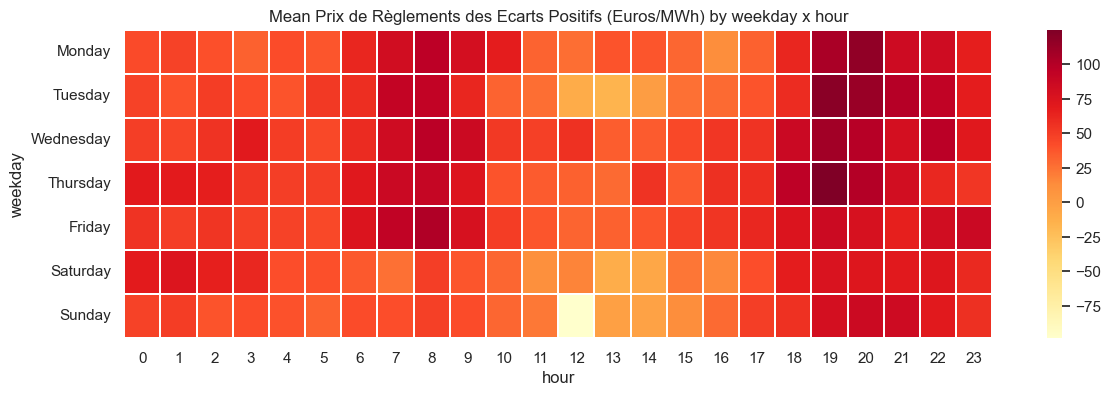

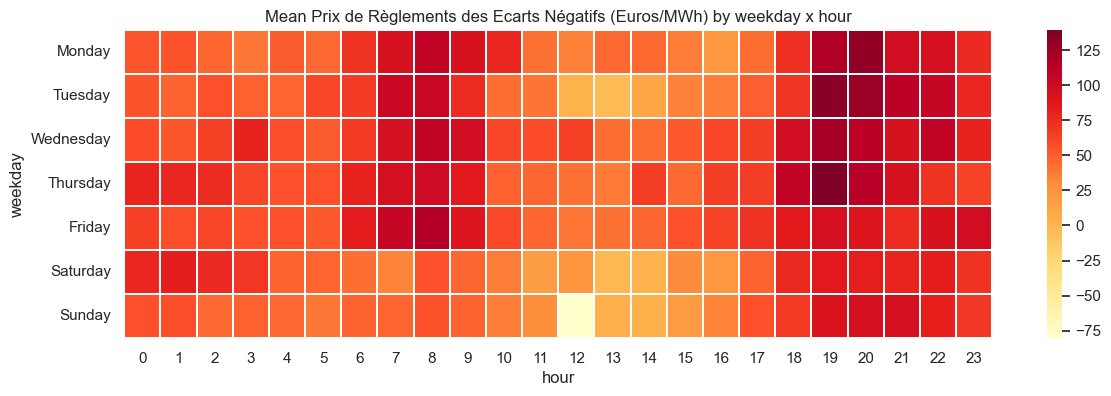

In [ ]:
for price_col in price_cols:
    pivot = df_all.pivot_table(
        index='weekday',
        columns='hour',
        values=price_col,
        aggfunc='mean',
        observed=True,
    )

    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
    plt.title(f'Mean {price_col} by weekday x hour')
    plt.xlabel('hour')
    plt.ylabel('weekday')
    plt.show()


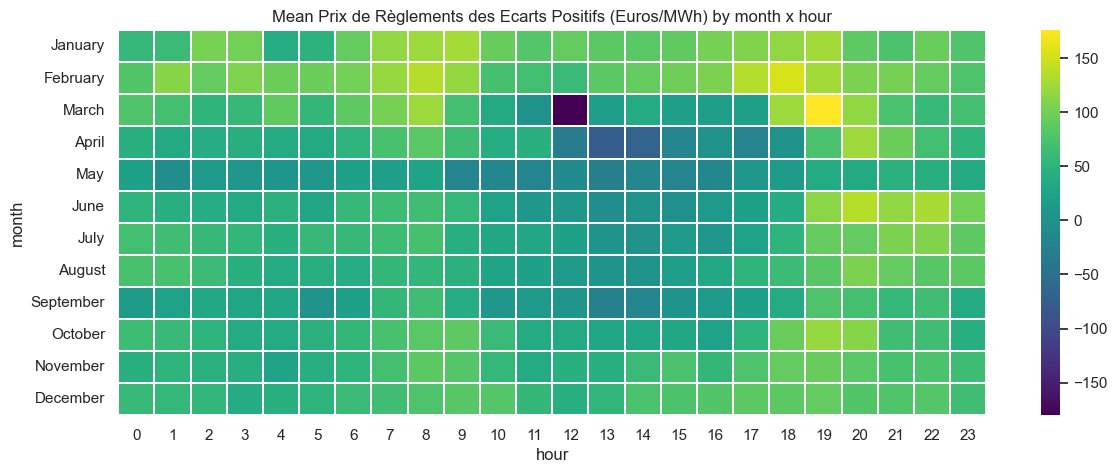

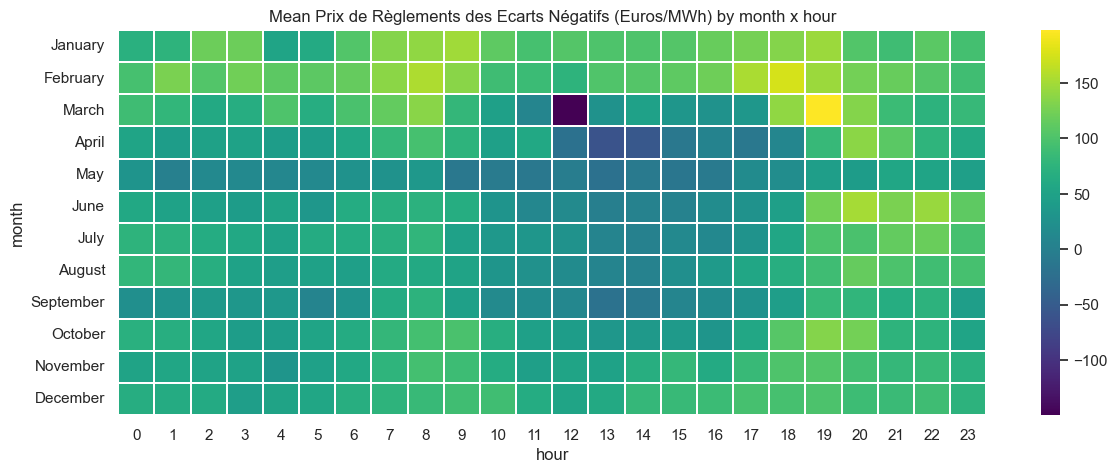

In [ ]:
for price_col in price_cols:
    pivot = df_all.pivot_table(
        index='month_name',
        columns='hour',
        values=price_col,
        aggfunc='mean',
        observed=True,
    )

    plt.figure(figsize=(14, 5))
    sns.heatmap(pivot, cmap='viridis', linewidths=0.3)
    plt.title(f'Mean {price_col} by month x hour')
    plt.xlabel('hour')
    plt.ylabel('month')
    plt.show()


## 5.2) Meme heatmaps, avec la valeur par quart d'heure

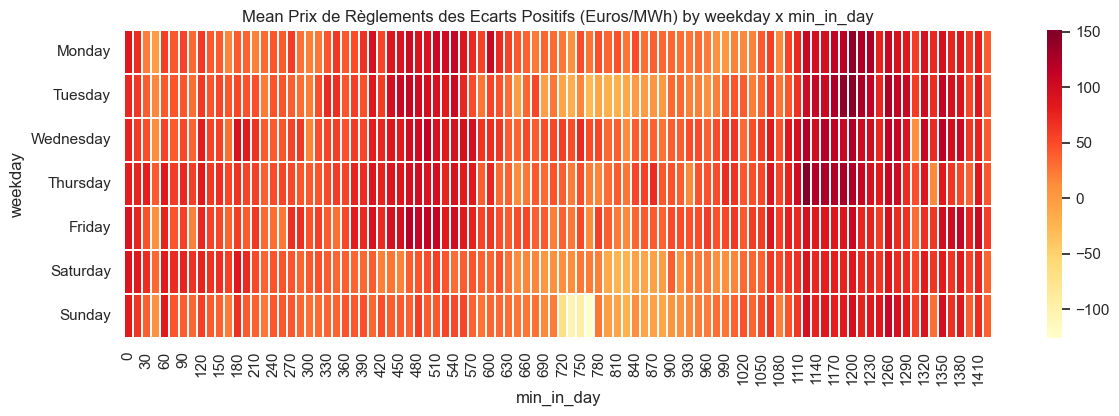

In [20]:
price_col = price_cols[0]
pivot = df_all.pivot_table(
    index='weekday',
    columns='min_in_day',
    values=price_col,
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title(f'Mean {price_col} by weekday x min_in_day')
plt.xlabel('min_in_day')
plt.ylabel('weekday')
plt.show()


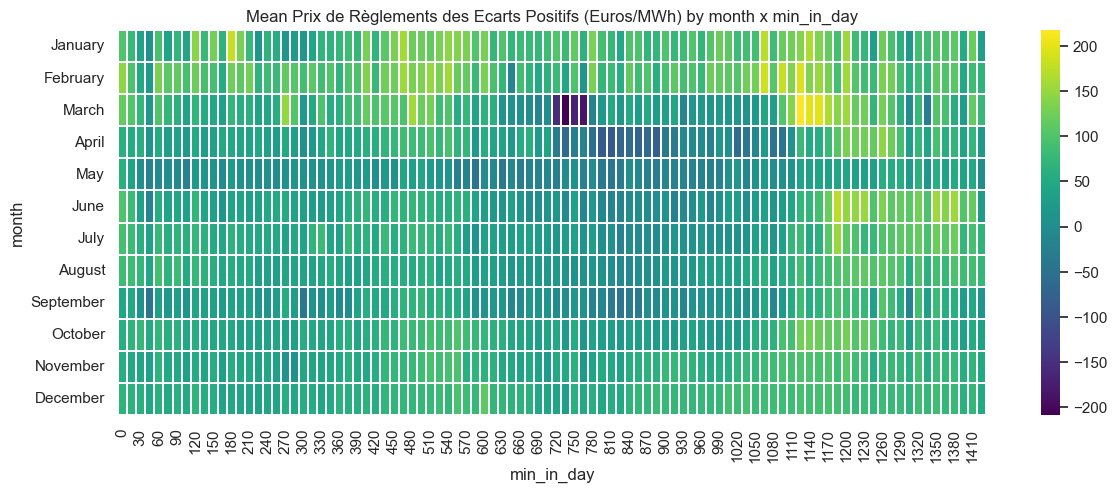

In [8]:
price_col = price_cols[0]
pivot = df_all.pivot_table(
    index='month_name',
    columns='min_in_day',
    values=price_col,
    aggfunc='mean',
    observed=True,
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='viridis', linewidths=0.3)
plt.title(f'Mean {price_col} by month x min_in_day')
plt.xlabel('min_in_day')
plt.ylabel('month')
plt.show()


## 5.3) Meme heatmaps, avec la valeur mediane

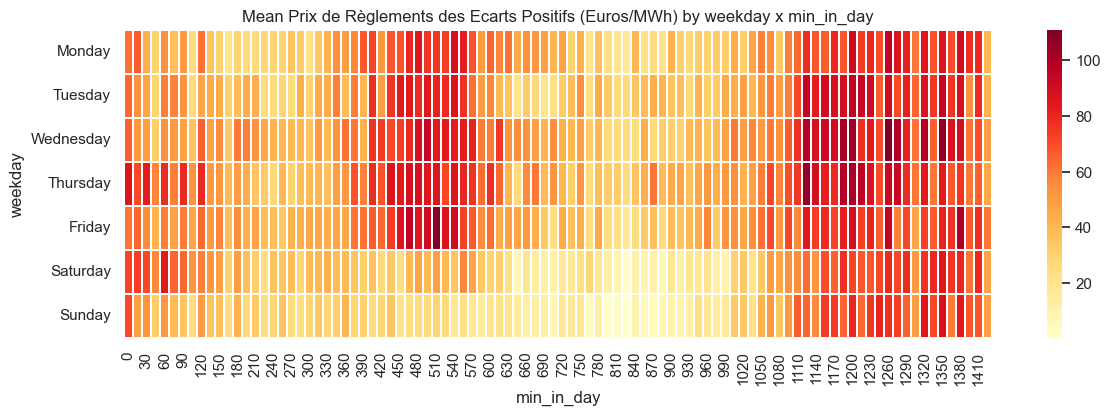

In [64]:
price_col = price_cols[0]
pivot = df_all.pivot_table(
    index='weekday',
    columns='min_in_day',
    values=price_col,
    aggfunc='median',
    observed=True,
)

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title(f'Mean {price_col} by weekday x min_in_day')
plt.xlabel('min_in_day')
plt.ylabel('weekday')
plt.show()


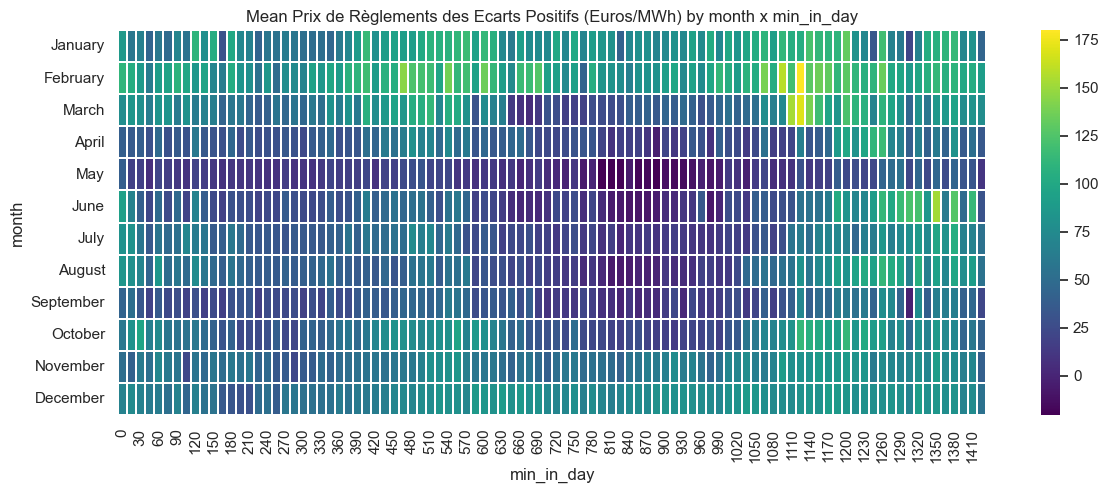

In [65]:
price_col = price_cols[0]
pivot = df_all.pivot_table(
    index='month_name',
    columns='min_in_day',
    values=price_col,
    aggfunc='median',
    observed=True,
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='viridis', linewidths=0.3)
plt.title(f'Mean {price_col} by month x min_in_day')
plt.xlabel('min_in_day')
plt.ylabel('month')
plt.show()


## 5.4) Quart d'heure, semaine, valeur mediane

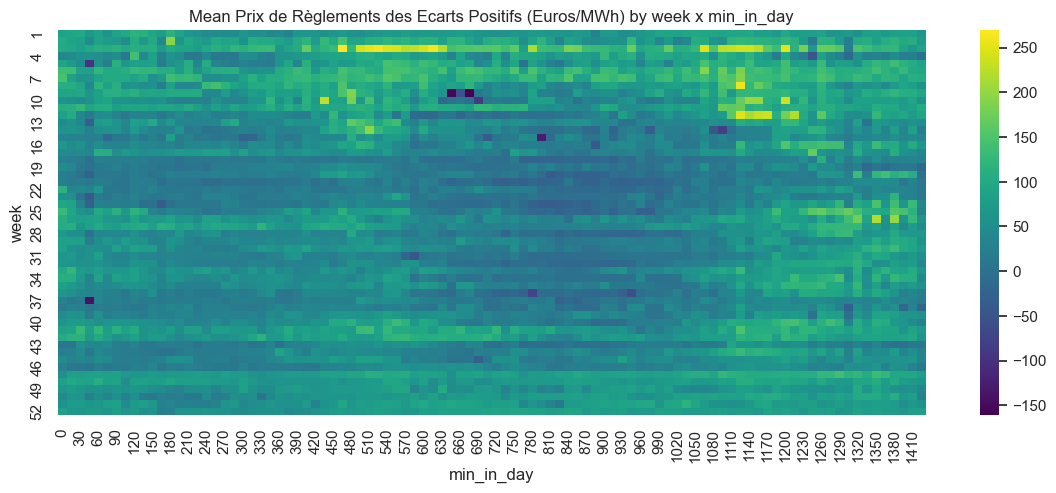

In [8]:
price_col = price_cols[0]
pivot = df_all.pivot_table(
    index='week_num',
    columns='min_in_day',
    values=price_col,
    aggfunc='median',
    observed=True,
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='viridis')
plt.title(f'Mean {price_col} by week x min_in_day')
plt.xlabel('min_in_day')
plt.ylabel('week')
plt.show()


## 6) Auto-correlation de la serie 15-min

Objectif: mesurer la dependance temporelle des 2 colonnes prix et verifier si les lags courts (15 min, 1h) et saisonniers (1 jour, 1 semaine) portent du signal.


In [ ]:
df_ts = df_all.sort_values(start_ts_col).set_index(start_ts_col)

# Check sampling regularity before interpreting autocorrelation.
step_counts = df_all.index.to_series().diff().dropna().value_counts().sort_index()
print('Top time steps (expected mostly 15 minutes):')
display(step_counts.tail(10))

def acf_by_lag(series: pd.Series, max_lag: int) -> pd.DataFrame:
    clean = series.dropna().astype(float)
    values = clean.to_numpy()
    n = len(values)
    if n <= max_lag + 1:
        raise ValueError(f'Not enough observations ({n}) for max_lag={max_lag}')

    centered = values - values.mean()
    denom = (centered ** 2).mean()
    if denom == 0:
        return pd.DataFrame({'lag': range(1, max_lag + 1), 'autocorr': [np.nan] * max_lag})

    out = []
    for lag in range(1, max_lag + 1):
        cov = (centered[:-lag] * centered[lag:]).mean()
        out.append(cov / denom)

    return pd.DataFrame({'lag': range(1, max_lag + 1), 'autocorr': out})

MAX_LAG = 7 * 24 * 4  # 7 days at 15-min resolution
SIGNIF_Z = 1.96  # Approx 95% CI under white-noise assumption


Top time steps (expected mostly 15 minutes):


Heure de début
0 days 00:00:00        4
0 days 00:15:00    35034
0 days 01:15:00        1
Name: count, dtype: int64

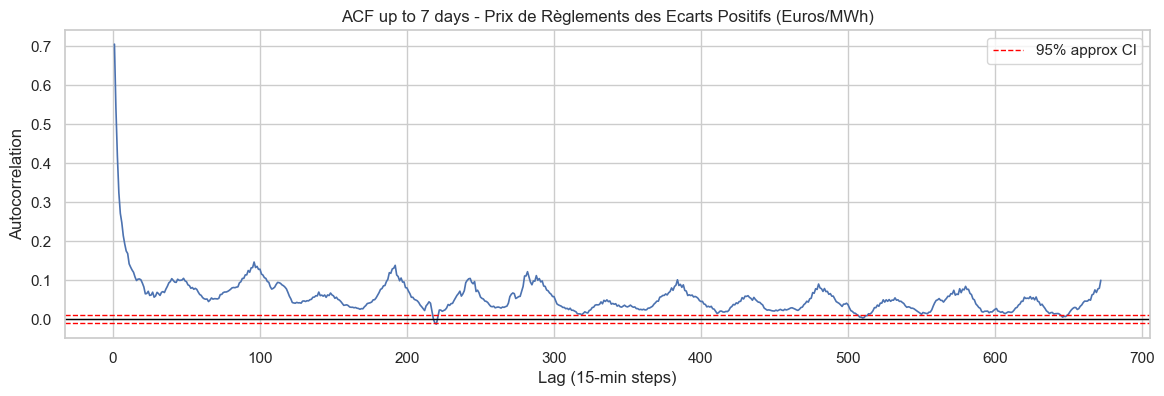

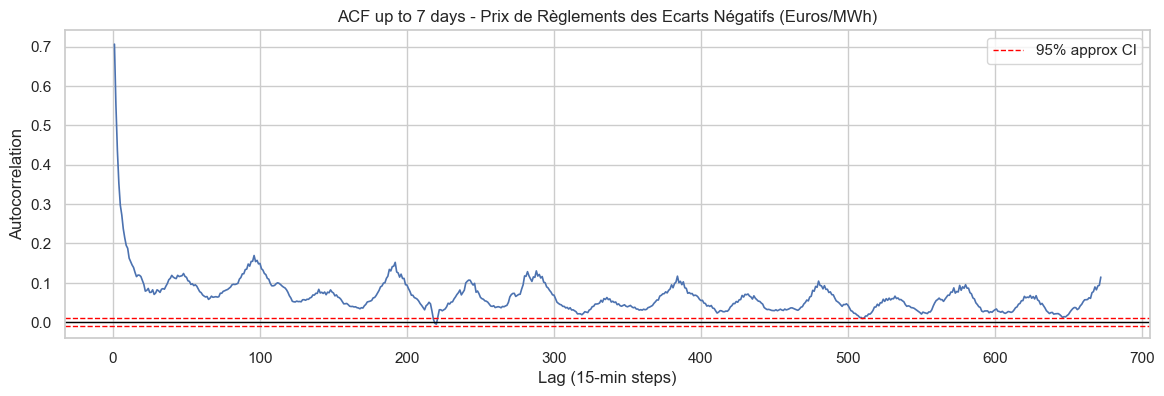

,price_col,Prix de Règlements des Ecarts Négatifs (Euros/MWh),Prix de Règlements des Ecarts Positifs (Euros/MWh)
lag,lag_label,,
1,15m,0.706206,0.704149
2,30m,0.551879,0.540335
4,1h,0.352858,0.323740
8,2h,0.214363,0.192354
12,3h,0.153985,0.133107
24,6h,0.085560,0.071125
48,12h,0.123512,0.104377
96,1d,0.169268,0.146094
192,2d,0.151889,0.137676


In [27]:
acf_results = {}

for price_col in price_cols:
    series = df_ts[price_col]
    acf_df = acf_by_lag(series, MAX_LAG)
    acf_results[price_col] = acf_df

    n = series.notna().sum()
    ci = SIGNIF_Z / np.sqrt(n)

    plt.figure(figsize=(14, 4))
    plt.plot(acf_df['lag'], acf_df['autocorr'], lw=1.2)
    plt.axhline(0.0, color='black', lw=1)
    plt.axhline(ci, color='red', ls='--', lw=1, label='95% approx CI')
    plt.axhline(-ci, color='red', ls='--', lw=1)
    plt.title(f'ACF up to 7 days - {price_col}')
    plt.xlabel('Lag (15-min steps)')
    plt.ylabel('Autocorrelation')
    plt.legend()
    plt.show()

key_lags = [1, 2, 4, 8, 12, 24, 48, 96, 192, 288, 672]
lag_labels = {1: '15m', 2: '30m', 4: '1h', 8: '2h', 12: '3h', 24: '6h', 48: '12h', 96: '1d', 192: '2d', 288: '3d', 672: '1w'}
rows = []

for price_col, acf_df in acf_results.items():
    lookup = acf_df.set_index('lag')['autocorr']
    for lag in key_lags:
        rows.append({
            'price_col': price_col,
            'lag': lag,
            'lag_label': lag_labels.get(lag, str(lag)),
            'autocorr': lookup.get(lag, np.nan),
        })

key_lag_acf = pd.DataFrame(rows).sort_values(['lag', 'price_col'])
display(key_lag_acf.pivot(index=['lag', 'lag_label'], columns='price_col', values='autocorr'))


### 6.1) Verification avec `plot_acf` (statsmodels)

Reproduction du style de `plots.py` avec `lags=7*24`, puis extension `lags=7*24*4` adaptee a une resolution 15-min.


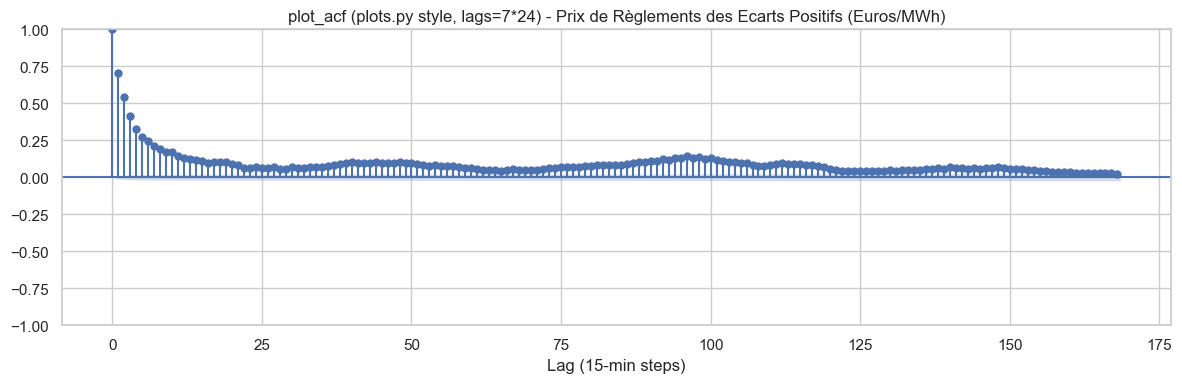

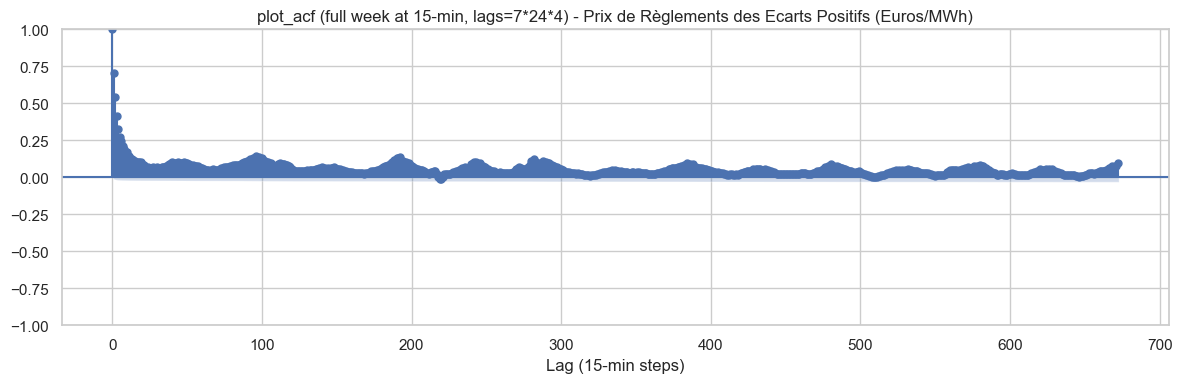

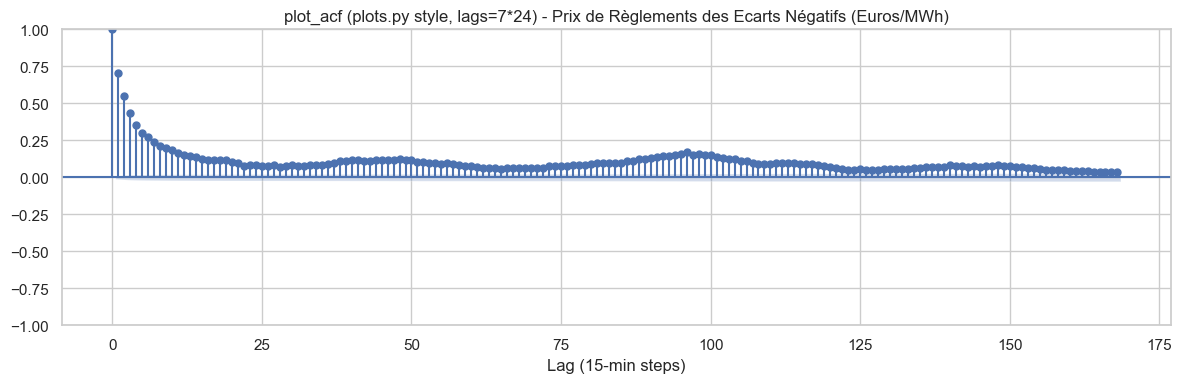

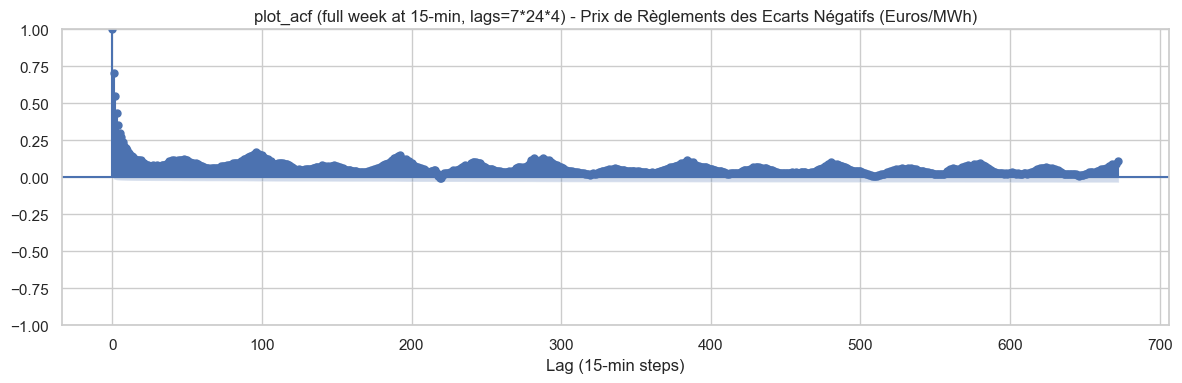

In [29]:
try:
    from statsmodels.graphics.tsaplots import plot_acf
    statsmodels_available = True
except Exception as exc:
    statsmodels_available = False
    print(f'statsmodels not available: {exc}')

if statsmodels_available:
    lags_like_plots_py = 7 * 24      # exactement comme plots.py
    lags_15min_week = 7 * 24 * 4    # 1 semaine complete a 15-min

    for price_col in price_cols:
        series = df_ts[price_col].dropna().astype(float)

        fig, ax = plt.subplots(figsize=(12, 4))
        _ = plot_acf(series, lags=lags_like_plots_py, ax=ax, alpha=0.05)
        ax.set_title(f'plot_acf (plots.py style, lags=7*24) - {price_col}')
        ax.set_xlabel('Lag (15-min steps)')
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(12, 4))
        _ = plot_acf(series, lags=lags_15min_week, ax=ax, alpha=0.05)
        ax.set_title(f'plot_acf (full week at 15-min, lags=7*24*4) - {price_col}')
        ax.set_xlabel('Lag (15-min steps)')
        plt.tight_layout()
        plt.show()


,price_col,month,acf_lag_1_15m,acf_lag_96_1d
12,Prix de Règlements des Ecarts Négatifs (Euros/...,1,0.627796,0.201528
13,Prix de Règlements des Ecarts Négatifs (Euros/...,2,0.533434,0.134609
14,Prix de Règlements des Ecarts Négatifs (Euros/...,3,0.695057,0.073776
15,Prix de Règlements des Ecarts Négatifs (Euros/...,4,0.770208,0.110177
16,Prix de Règlements des Ecarts Négatifs (Euros/...,5,0.601886,0.126860
17,Prix de Règlements des Ecarts Négatifs (Euros/...,6,0.773827,0.149689
18,Prix de Règlements des Ecarts Négatifs (Euros/...,7,0.704744,0.184057
19,Prix de Règlements des Ecarts Négatifs (Euros/...,8,0.743119,0.266562
20,Prix de Règlements des Ecarts Négatifs (Euros/...,9,0.680523,0.144867
21,Prix de Règlements des Ecarts Négatifs (Euros/...,10,0.752001,0.211971


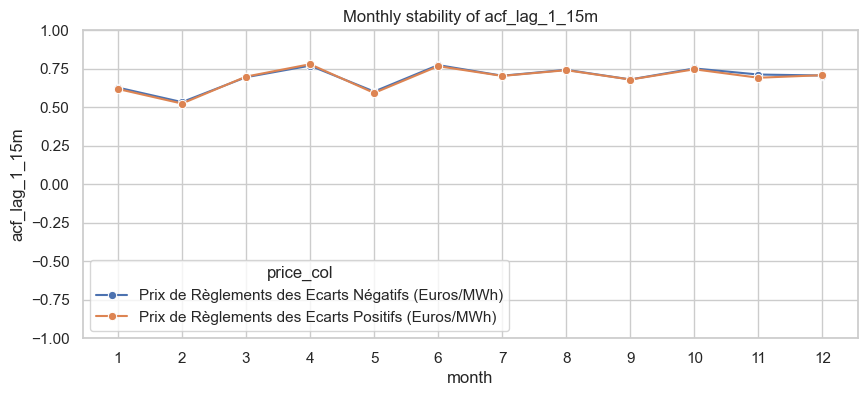

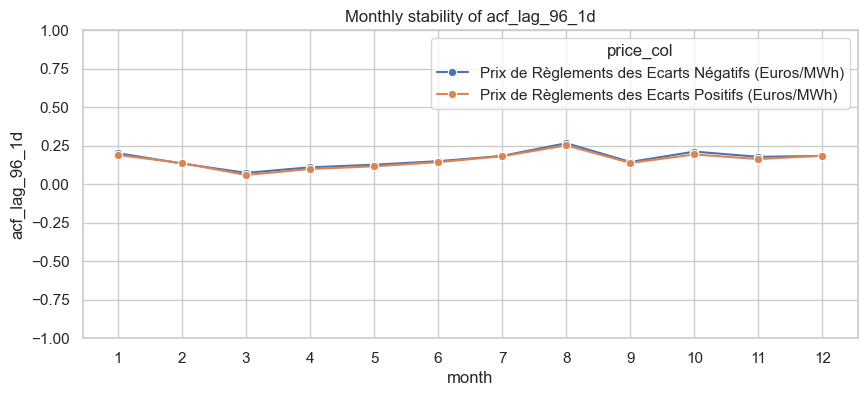

In [28]:
def safe_autocorr(series: pd.Series, lag: int) -> float:
    s = series.dropna()
    if len(s) <= lag:
        return np.nan
    return s.autocorr(lag=lag)

monthly_rows = []
for price_col in price_cols:
    for month, grp in df_ts.groupby(df_ts.index.month)[price_col]:
        monthly_rows.append({
            'price_col': price_col,
            'month': int(month),
            'acf_lag_1_15m': safe_autocorr(grp, 1),
            'acf_lag_96_1d': safe_autocorr(grp, 96),
        })

monthly_acf = pd.DataFrame(monthly_rows).sort_values(['price_col', 'month'])
display(monthly_acf)

for metric in ['acf_lag_1_15m', 'acf_lag_96_1d']:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=monthly_acf, x='month', y=metric, hue='price_col', marker='o')
    plt.title(f'Monthly stability of {metric}')
    plt.xticks(range(1, 13))
    plt.ylim(-1, 1)
    plt.show()


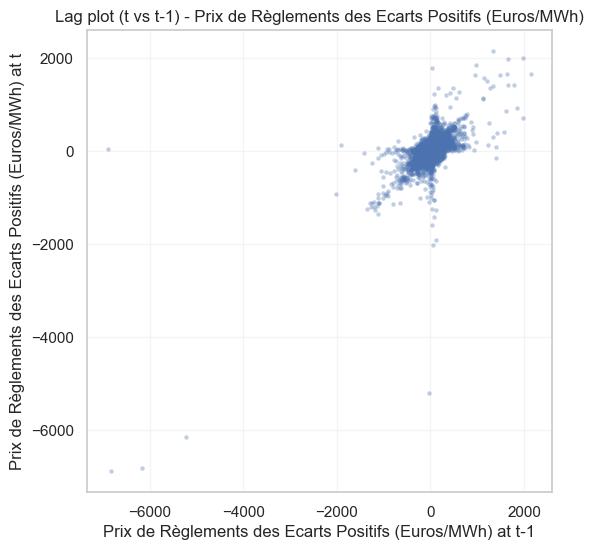

In [11]:
target_col = 'Prix de Règlements des Ecarts Positifs (Euros/MWh)'
if target_col not in df_all.columns:
    candidates = [c for c in df_all.columns if 'Prix de Règlements des Ecarts Positifs' in c]
    if not candidates:
        raise KeyError('Positive imbalance settlement price column not found in df_all')
    target_col = candidates[0]

series = df_all[target_col].dropna().astype(float)
lag_df = pd.DataFrame({'t-1': series.shift(1), 't': series}).dropna()

plt.figure(figsize=(6, 6))
sns.scatterplot(data=lag_df, x='t-1', y='t', s=10, alpha=0.35, linewidth=0)
plt.title(f'Lag plot (t vs t-1) - {target_col}')
plt.xlabel(f'{target_col} at t-1')
plt.ylabel(f'{target_col} at t')
plt.grid(alpha=0.2)
plt.show()


## 7) Points de controle rapides

- Verifier que chaque mois 2025 est present dans `file_index_df`.
- Verifier la construction de `holiday_fr` / `is_holiday_fr` sur les dates 2025.
- Lire les ACF aux lags 1, 4, 96, 672 pour valider la memoire court terme et la saisonnalite.
- Ajuster les composantes combinees dans `combined_components` selon les hypotheses metier.


In [23]:
df_all

,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file,weekday,weekday_num,month,month_name,hour,minute,date_only,holiday_fr,is_holiday_fr
0,2025-01-01 00:00:00,2025-01-01 00:15:00,577.68,BAISSE,20.34,23.28,MMA_HECAR_2025 (10).csv,Wednesday,2,1,January,0,0,2025-01-01,New Year,True
1,2025-01-01 00:15:00,2025-01-01 00:30:00,190.33,BAISSE,19.22,22.00,MMA_HECAR_2025 (10).csv,Wednesday,2,1,January,0,15,2025-01-01,New Year,True
2,2025-01-01 00:30:00,2025-01-01 00:45:00,201.93,BAISSE,32.13,36.79,MMA_HECAR_2025 (10).csv,Wednesday,2,1,January,0,30,2025-01-01,New Year,True
3,2025-01-01 00:45:00,2025-01-01 01:00:00,338.08,BAISSE,29.13,33.35,MMA_HECAR_2025 (10).csv,Wednesday,2,1,January,0,45,2025-01-01,New Year,True
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.81,BAISSE,13.24,15.16,MMA_HECAR_2025 (10).csv,Wednesday,2,1,January,1,0,2025-01-01,New Year,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,2025-12-31 22:45:00,2025-12-31 23:00:00,244.17,BAISSE,62.66,69.40,MMA_HECAR_2025.csv,Wednesday,2,12,December,22,45,2025-12-31,Non-holiday,False
35036,2025-12-31 23:00:00,2025-12-31 23:15:00,96.15,BAISSE,84.02,93.06,MMA_HECAR_2025.csv,Wednesday,2,12,December,23,0,2025-12-31,Non-holiday,False
35037,2025-12-31 23:15:00,2025-12-31 23:30:00,152.47,BAISSE,87.04,96.40,MMA_HECAR_2025.csv,Wednesday,2,12,December,23,15,2025-12-31,Non-holiday,False
35038,2025-12-31 23:30:00,2025-12-31 23:45:00,131.69,BAISSE,70.04,77.56,MMA_HECAR_2025.csv,Wednesday,2,12,December,23,30,2025-12-31,Non-holiday,False
